In [ ]:
from pathlib import Path
import nibabel as nib 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import load_img, index_img
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
proj_path = Path("/mnt/1e99f03a-239b-4885-af31-60eb1322a5e1/IEL/sklearn")

for subj in range(1, 2):
    proj = 'IEL'

    if subj < 10:
        part_id = f"IEL00{subj}"
    else:
        part_id = f"IEL0{subj}"

    
    if subj < 10 :
        part_id = f"IEL00{subj}"
    else:
        part_id = f"IEL0{subj}"

    # skip removed subject
    if part_id == "IEL006":
        continue


    beta_paths = []
    part_file = Path(f"{proj_path}/behaviour/{part_id}_master_file.csv")
    part_df = pd.read_csv(part_file)

    # Initialize separate sequence counters for each condition block (starting at 0)
    loss_pos_count = 0
    noloss_pos_count = 0
    loss_neu_count = 0
    noloss_neu_count = 0

    # Loop safely through the dataframe rows
    for i in range(len(part_df)):
        trial = part_df['TrialNumber'].iloc[i]
        emo = part_df['Emotion'].iloc[i]
        loss = part_df['Loss'].iloc[i]

        # Check conditions, build the label using the correct counter, and increment it
        if loss == 'Loss' and emo == 'Positive':
            condition_folder = 'Cue_Loss_Positive'
            condition_trial_label = f"Cue_Loss_Positive_{loss_pos_count}"
            loss_pos_count = loss_pos_count + 1
            
        elif loss == 'NoLoss' and emo == 'Positive':
            condition_folder = 'Cue_NoLoss_Positive'
            condition_trial_label = f"Cue_NoLoss_Positive_{noloss_pos_count}"
            noloss_pos_count = noloss_pos_count + 1
            
        elif loss == 'Loss' and emo == 'Neutral':
            condition_folder = 'Cue_Loss_Neutral'
            condition_trial_label = f"Cue_Loss_Neutral_{loss_neu_count}"
            loss_neu_count = loss_neu_count + 1
            
        elif loss == 'NoLoss' and emo == 'Neutral':
            condition_folder = 'Cue_NoLoss_Neutral'
            condition_trial_label = f"Cue_NoLoss_Neutral_{noloss_neu_count}"
            noloss_neu_count = noloss_neu_count + 1
            
        else:
            condition_trial_label = "UNKNOWN_CONDITION"

        # Combine the file path with the constructed label string
        beta_clean_file = (proj_path / "data" / "individual" / part_id / "BetaSeries" / condition_folder)
        specific_path = f"{beta_clean_file}/{condition_trial_label}.nii.gz"
        beta_paths.append(specific_path)
        
    # Append the paths to the dataframe and print
    part_df['Beta_Path'] = beta_paths  
    #print(part_df[['TrialNumber', 'Loss', 'Emotion', 'Beta_Path']].tail())
    #display(part_df.tail())

    #write to a MVPA/Nilearn subject specific path
    output_dir = Path(f"{proj_path}/data/individual/{part_id}/Metadata/")
    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir/f"{part_id}_dataset.csv"
    part_df.to_csv(file_path, index=True)

    

Processing IEL001
Loaded metadata: 121 trials
Usable trials: 121
Runs: 4
Classes: 2
Processing ROI: LeftAmyg
Loading beta:
/mnt/1e99f03a-239b-4885-af31-60eb1322a5e1/IEL/sklearn/data/individual/IEL001/BetaSeries/Cue_Loss_Positive/Cue_Loss_Positive_0.nii.gz
Loading beta:
/mnt/1e99f03a-239b-4885-af31-60eb1322a5e1/IEL/sklearn/data/individual/IEL001/BetaSeries/Cue_NoLoss_Neutral/Cue_NoLoss_Neutral_0.nii.gz
Loading beta:
/mnt/1e99f03a-239b-4885-af31-60eb1322a5e1/IEL/sklearn/data/individual/IEL001/BetaSeries/Cue_NoLoss_Neutral/Cue_NoLoss_Neutral_1.nii.gz
Loading beta:
/mnt/1e99f03a-239b-4885-af31-60eb1322a5e1/IEL/sklearn/data/individual/IEL001/BetaSeries/Cue_Loss_Positive/Cue_Loss_Positive_1.nii.gz
Loading beta:
/mnt/1e99f03a-239b-4885-af31-60eb1322a5e1/IEL/sklearn/data/individual/IEL001/BetaSeries/Cue_Loss_Positive/Cue_Loss_Positive_2.nii.gz
Loading beta:
/mnt/1e99f03a-239b-4885-af31-60eb1322a5e1/IEL/sklearn/data/individual/IEL001/BetaSeries/Cue_NoLoss_Neutral/Cue_NoLoss_Neutral_2.nii.gz
Loa

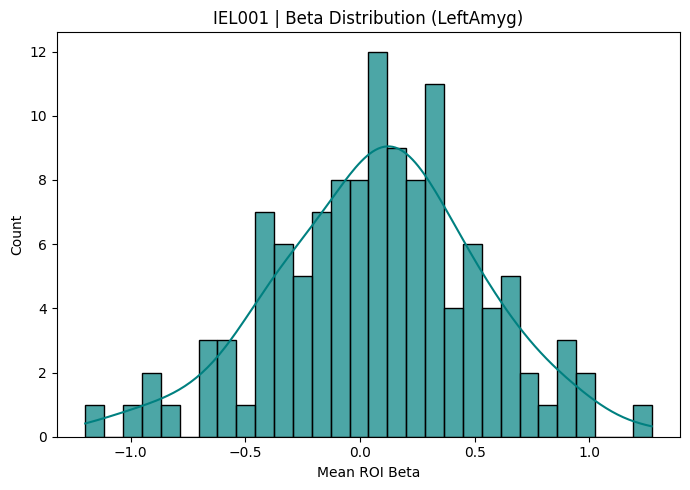

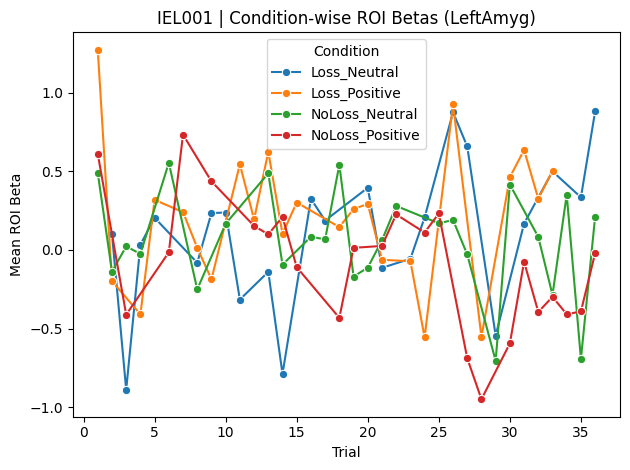

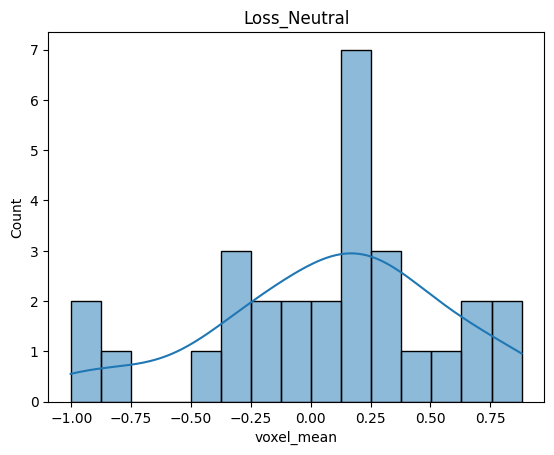

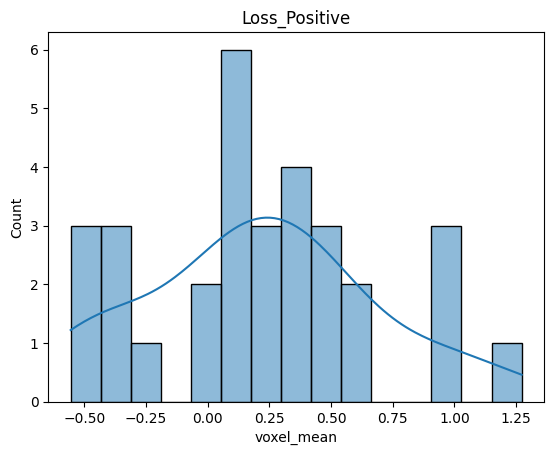

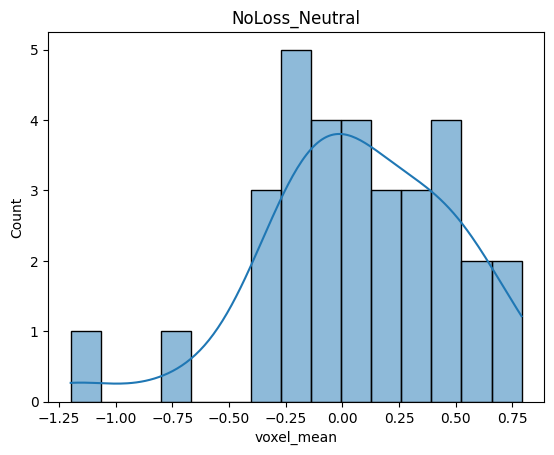

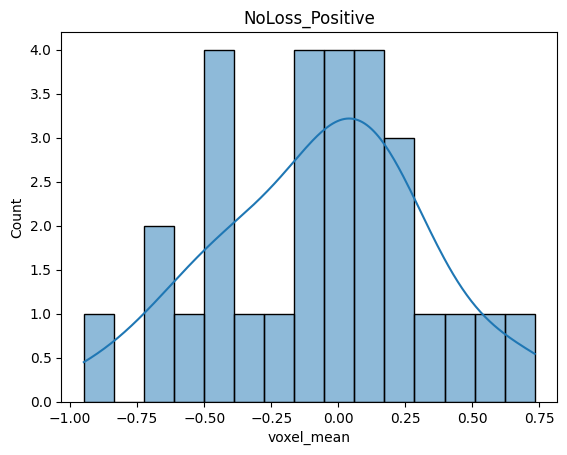

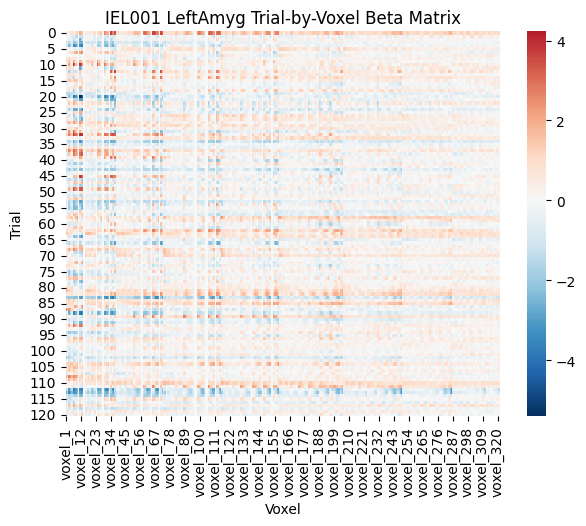

All Subjects Complete


In [ ]:

# ROI Beta extraction steps
# Steps
# 1. Define paths and settings
# 2. Load subject metadata
# 3. Run basic QC checks
# 4. Load beta images
# 5. Resample ROI mask if needed
# 6. Extract ROI voxel betas
# 7. Save ROI beta matrix
# 8. Save QC report

import os
from pathlib import Path

import pandas as pd
import nilearn

from nilearn.image import load_img, resample_to_img
from nilearn.masking import apply_mask


# Basic paths
proj_path = "/mnt/1e99f03a-239b-4885-af31-60eb1322a5e1/IEL/sklearn"
temp_path = "/media/cogemolab/home2/templates"

# ROI definitions
ROI_dict = {
    "LeftAmyg": "HarvardOxford-sub-maxprob-thr50-2mm_LAmyg_F.nii.gz"}
    #"RightAmyg": "HarvardOxford-sub-maxprob-thr50-2mm_RAmyg_F.nii.gz"}


def get_roi_mask_path(roi_name):
    roi_file = ROI_dict[roi_name]
    roi_path = os.path.join(temp_path, roi_file)
    return roi_path

# Subject file directories
def participant_id(subj):
    proj = "IEL"
    subj = f"{subj:03d}"
    part_id = f"{proj}{subj}"
    return part_id

def get_subject_paths(subj):
    part_id = participant_id(subj)
    paths = {
        # Metadata file
        "metadata_file": os.path.join(proj_path,
            "data",
            "individual",
            part_id,
            "Metadata",
            f"{part_id}_dataset.csv"),

        # Output directory
        "output_dir": os.path.join(
            proj_path,
            "data",
            "individual",
            part_id,
            "BetaSeries",
            "ROI")}

    return paths

# Loop through subjects
for subj in range(1,2):

    # Subject paths
    paths = get_subject_paths(subj)
    metadata_file = paths["metadata_file"]
    output_dir = paths["output_dir"]
    part_id = participant_id(subj)

    # skip removed subject
    if part_id == "IEL006":
        continue

    # Create output folder
    Path(output_dir).mkdir(parents=True,exist_ok=True)
    print(f"Processing {part_id}")

    # Load metadata
    df = pd.read_csv(metadata_file)
    print(f"Loaded metadata: {len(df)} trials")

    # Check if beta files exist
    df["beta_exists"] = df["Beta_Path"].apply(lambda x: Path(x).exists())

    # Basic QC check
    n_trials = len(df)
    n_runs = df["Run"].nunique()
    n_classes = df["Emotion"].nunique()
    print(f"Usable trials: {n_trials}")
    print(f"Runs: {n_runs}")
    print(f"Classes: {n_classes}")

    # Load ROI mask
    for roi_name in ROI_dict.keys():
        print(f"Processing ROI: {roi_name}")

        # Load ROI
        roi_mask_path = get_roi_mask_path(roi_name)
        roi_mask = load_img(roi_mask_path)

        # Storing ROI betas
        all_rows = []

        # Loop through the trials
        for idx, row in df.iterrows():
            beta_path = row["Beta_Path"]
            print(f"Loading beta:\n{beta_path}")

            # Load AFNI .nii
            beta_img = load_img(beta_path)

            # Resample mask if dimension mismatch
            if beta_img.shape != roi_mask.shape:
                roi_mask_resampled = resample_to_img(
                    roi_mask,
                    beta_img,
                    interpolation="nearest")
            else:
                roi_mask_resampled = roi_mask

            roi_values = apply_mask(
                beta_img,
                roi_mask_resampled)

            # Extract ROI voxel
            roi_values = apply_mask(
                beta_img,
                roi_mask_resampled)

            # Emyty ROI check
            if len(roi_values) == 0:
                print("WARNING: Empty ROI")
                continue

            # Create output row in the dataframe
            out_row = {
                "Subject": part_id,
                "Trial": row["TrialNumber"],
                "Run": row["Run"],
                "Emotion": row["Emotion"],
                "Loss": row["Loss"],
                "Beta_Path": beta_path}

            # Add voxel values
            for v in range(len(roi_values)):
                out_row[f"voxel_{v+1}"] = roi_values[v]
            all_rows.append(out_row)

        # Create dataframe for ROI values
        roi_df = pd.DataFrame(all_rows)

        # Save the ROI values dataframe
        roi_output_file = os.path.join(output_dir,f"{part_id}_{roi_name}_betas.csv")
        roi_df.to_csv(roi_output_file,sep="\t",index=False)
        
        # Save QC Report
        qc_row = {"subject": part_id,
            "n_trials": n_trials,
            "n_runs": n_runs,
            "n_positive": (df["Emotion"] == "Positive").sum(),
            "n_Neutral": (df["Emotion"] == "Neutral").sum()}

        qc_df = pd.DataFrame([qc_row])
        qc_output_file = os.path.join(output_dir,f"{part_id}_qc_report.tsv")
        qc_df.to_csv(qc_output_file,sep="\t",index=False)

        print("\nSaved QC report")
        print(qc_output_file)

        # Visualising betas

        voxel_col = roi_df.columns[roi_df.columns.str.startswith('voxel_')]
        roi_df['voxel_mean'] = np.mean(roi_df[voxel_col], axis=1)
        roi_df["Condition"] = (
        roi_df["Loss"].astype(str) + "_" +
        roi_df["Emotion"].astype(str) )
        # beta trend across trials
        plt.figure(figsize=(7, 5))

        sns.histplot(
            roi_df["voxel_mean"],
            bins=30,
            kde=True,
            color="teal",
            edgecolor="black",
            alpha=0.7)

        plt.title(f"{part_id} | Beta Distribution ({roi_name})")
        plt.xlabel("Mean ROI Beta")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

        # betas distribution per condition
        trial_cond_df = (roi_df.groupby(["Condition", "Trial"], as_index=False)["voxel_mean"].mean())

        sns.lineplot(
            data=trial_cond_df,
            x="Trial",
            y="voxel_mean",
            hue="Condition",
            marker="o")

        plt.title(f"{part_id} | Condition-wise ROI Betas ({roi_name})")
        plt.xlabel("Trial")
        plt.ylabel("Mean ROI Beta")
        #plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()


        for condition, cond_df in roi_df.groupby("Condition"):
            plt.figure()
            sns.histplot(cond_df["voxel_mean"], bins=15, kde=True).set_title(condition)  

        # trial by voxel beta matrix
        plt.figure(figsize=(7,5))
        sns.heatmap(
            roi_df[voxel_col],
            cmap="RdBu_r",
            center=0)

        plt.xlabel("Voxel")
        plt.ylabel("Trial")
        plt.title(f"{part_id} {roi_name} Trial-by-Voxel Beta Matrix")
        plt.show()                      


print("All Subjects Complete")

